# UNet

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torchmetrics

import glob
import math
import sys
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional.image import structural_similarity_index_measure

# ============================================================
# SETUP PATH
# ============================================================

WORK_DIR = Path("/content/drive/MyDrive/Computational Imaging/Code")
RETINA_DATASET_PATH = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images")

# Cartella dove salveremo il dataset preprocessato in .pt
PROCESSED_DATASET_DIR = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retina_processed")

# Find IPPy folder
for base in (WORK_DIR, *WORK_DIR.parents):
    if (base / "IPPy").exists():
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Could not find IPPy folder.")

from IPPy import operators, utilities

device = utilities.get_device()
torch.manual_seed(0)

print("Device:", device)
print("Working directory:", WORK_DIR)
print("Retina dataset path:", RETINA_DATASET_PATH)
print("Processed dataset path:", PROCESSED_DATASET_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.6 MB/s eta 0:00:0000:01
Device: cuda
Working directory: /content/drive/MyDrive/Computational Imaging/Code
Retina dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images
Processed dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed


## Dataset

In [3]:
class RetinaPTDataset(Dataset):
    def __init__(self, pt_path):
        super().__init__()

        payload = torch.load(pt_path, map_location="cpu")

        self.clean = payload["clean"]
        self.degraded = payload["degraded"]
        self.source_paths = payload["source_paths"]
        self.metadata = payload["metadata"]

    def __len__(self):
        return self.clean.shape[0]

    def __getitem__(self, idx):
        y = self.degraded[idx]   # input degradato
        x = self.clean[idx]      # target pulito
        return y, x

def noise_file_name(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}.pt"

## Dataloader

In [4]:
# ============================================================
# DATALOADERS FOR DIFFERENT NOISE LEVELS
# ============================================================

NOISE_LEVELS = [0.1]
batch_size = 8


def create_dataloaders_for_noise(noise_level):
    train_pt = PROCESSED_DATASET_DIR / "train" / noise_file_name(noise_level)
    val_pt = PROCESSED_DATASET_DIR / "validation" / noise_file_name(noise_level)
    test_pt = PROCESSED_DATASET_DIR / "test" / noise_file_name(noise_level)

    train_dataset_pt = RetinaPTDataset(train_pt)
    val_dataset_pt = RetinaPTDataset(val_pt)
    test_dataset_pt = RetinaPTDataset(test_pt)

    train_loader = DataLoader(
        train_dataset_pt,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset_pt,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset_pt,
        batch_size=batch_size,
        shuffle=False,
    )

    print("Noise level:", noise_level)
    print("Train samples:", len(train_dataset_pt))
    print("Validation samples:", len(val_dataset_pt))
    print("Test samples:", len(test_dataset_pt))
    print("Metadata:", train_dataset_pt.metadata)

    return train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt

## UNet

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ):
        super().__init__()

        self.final_sigmoid = final_sigmoid

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2,
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(
                    x,
                    size=skip_connection.shape[2:],
                    mode="bilinear",
                    align_corners=False,
                )

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](x)

        x = self.final_conv(x)

        if self.final_sigmoid:
            x = torch.sigmoid(x)

        return x

In [6]:
model = UNet(
    in_channels=1,
    out_channels=1,
    features=(32, 64, 128, 256),
).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

print("Number of parameters:", sum(p.numel() for p in model.parameters()))

Number of parameters: 7759521


## Train & Validation

In [7]:

def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    for y, x in tqdm(dataloader, desc="Training", leave=False):
        y = y.to(device).clamp(0, 1)
        x = x.to(device).clamp(0, 1)

        optimizer.zero_grad()

        x_hat = model(y)
        loss = loss_fn(x_hat, x)

        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size

        with torch.no_grad():
            x_hat_eval = x_hat.clamp(0, 1)
            batch_psnr = compute_psnr(x_hat_eval, x)
            total_psnr += batch_psnr.sum().item()

        total_samples += batch_size

    return total_loss / total_samples, total_psnr / total_samples


def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    with torch.no_grad():
        for y, x in tqdm(dataloader, desc="Validation", leave=False):
            y = y.to(device).clamp(0, 1)
            x = x.to(device).clamp(0, 1)

            x_hat = model(y)
            loss = loss_fn(x_hat, x)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size

            x_hat_eval = x_hat.clamp(0, 1)
            batch_psnr = compute_psnr(x_hat_eval, x)
            total_psnr += batch_psnr.sum().item()

            total_samples += batch_size

    return total_loss / total_samples, total_psnr / total_samples


## Outputs' folder

In [8]:
# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = WORK_DIR.parent / "outputs" / "unet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved in:", OUTPUT_DIR)

Outputs will be saved in: /content/drive/MyDrive/Computational Imaging/outputs/unet


In [9]:

# ============================================================
# METRICS AND OUTPUT SAVING FUNCTIONS
# ============================================================

def noise_tag(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}"


def compute_psnr(x_hat, x, max_val=1.0):
    mse = torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))
    mse = torch.clamp(mse, min=1e-12)
    psnr = 10 * torch.log10(max_val ** 2 / mse)
    return psnr


def compute_ssim_per_image(x_hat, x):
    x_hat = x_hat.clamp(0, 1)
    x = x.clamp(0, 1)

    values = []
    for i in range(x.shape[0]):
        value = structural_similarity_index_measure(
            x_hat[i:i+1],
            x[i:i+1],
            data_range=1.0,
        )
        values.append(value.detach().cpu())

    return torch.stack(values)


def evaluate_model(model, test_loader, device):
    model.eval()

    psnr_degraded_list = []
    psnr_unet_list = []
    mse_degraded_list = []
    mse_unet_list = []
    ssim_degraded_list = []
    ssim_unet_list = []

    with torch.no_grad():
        for y, x in tqdm(test_loader, desc="Testing", leave=False):
            y = y.to(device).clamp(0, 1)
            x = x.to(device).clamp(0, 1)

            x_hat = model(y).clamp(0, 1)

            psnr_degraded = compute_psnr(y, x)
            psnr_unet = compute_psnr(x_hat, x)

            mse_degraded = torch.mean((y - x) ** 2, dim=(1, 2, 3))
            mse_unet = torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))

            ssim_degraded = compute_ssim_per_image(y, x)
            ssim_unet = compute_ssim_per_image(x_hat, x)

            psnr_degraded_list.append(psnr_degraded.cpu())
            psnr_unet_list.append(psnr_unet.cpu())
            mse_degraded_list.append(mse_degraded.cpu())
            mse_unet_list.append(mse_unet.cpu())
            ssim_degraded_list.append(ssim_degraded)
            ssim_unet_list.append(ssim_unet)

    psnr_degraded_all = torch.cat(psnr_degraded_list)
    psnr_unet_all = torch.cat(psnr_unet_list)
    mse_degraded_all = torch.cat(mse_degraded_list)
    mse_unet_all = torch.cat(mse_unet_list)
    ssim_degraded_all = torch.cat(ssim_degraded_list)
    ssim_unet_all = torch.cat(ssim_unet_list)

    results = {
        "psnr_degraded": psnr_degraded_all.mean().item(),
        "psnr_degraded_std": psnr_degraded_all.std(unbiased=False).item(),
        "psnr_unet": psnr_unet_all.mean().item(),
        "psnr_unet_std": psnr_unet_all.std(unbiased=False).item(),
        "mse_degraded": mse_degraded_all.mean().item(),
        "mse_unet": mse_unet_all.mean().item(),
        "ssim_degraded": ssim_degraded_all.mean().item(),
        "ssim_degraded_std": ssim_degraded_all.std(unbiased=False).item(),
        "ssim_unet": ssim_unet_all.mean().item(),
        "ssim_unet_std": ssim_unet_all.std(unbiased=False).item(),
    }

    return results


@torch.no_grad()
def check_output_range(model, dataloader, device):
    model.eval()

    total_outside = 0
    total_values = 0

    raw_min = float("inf")
    raw_max = float("-inf")

    for y, _ in tqdm(dataloader, desc="Checking output range", leave=False):
        y = y.to(device).clamp(0, 1)

        # Output RAW: niente clamp qui
        raw = model(y)

        total_outside += ((raw < 0) | (raw > 1)).sum().item()
        total_values += raw.numel()

        raw_min = min(raw_min, raw.min().item())
        raw_max = max(raw_max, raw.max().item())

    fraction_outside = total_outside / total_values

    print(f"Fraction outside [0,1]: {fraction_outside:.6%}")
    print(f"Raw min/max: {raw_min:.6f} / {raw_max:.6f}")

    return {
        "fraction_outside": fraction_outside,
        "raw_min": raw_min,
        "raw_max": raw_max,
    }

@torch.no_grad()
def evaluate_raw_vs_clamped(model, test_loader, device):
    model.eval()

    psnr_raw_all = []
    ssim_raw_all = []

    psnr_clamped_all = []
    ssim_clamped_all = []

    for y, x in tqdm(test_loader, desc="Raw vs clamped", leave=False):
        y = y.to(device).clamp(0, 1)
        x = x.to(device).clamp(0, 1)

        raw = model(y)
        clamped = raw.clamp(0, 1)

        # Raw output metrics
        raw_for_metrics = raw.clamp(0, 1)  
        # Nota: molte implementazioni SSIM/PSNR assumono range [0,1].
        # Per una metrica veramente "raw", vedi la versione sotto.

        for i in range(x.shape[0]):
            gt = x[i:i+1]

            psnr_clamped_all.append(psnr_torch(clamped[i:i+1], gt).item())
            ssim_clamped_all.append(ssim_torch(clamped[i:i+1], gt).item())

    print(f"Clamped PSNR: {np.mean(psnr_clamped_all):.4f} dB")
    print(f"Clamped SSIM: {np.mean(ssim_clamped_all):.4f}")

@torch.no_grad()
def check_clamp_impact(model, dataloader, device):
    model.eval()

    total_raw_mse = 0.0
    total_clamped_mse = 0.0
    total_samples = 0

    total_negative = 0
    total_values = 0
    negative_sum = 0.0
    negative_abs_sum = 0.0

    for y, x in tqdm(dataloader, desc="Checking clamp impact", leave=False):
        y = y.to(device).clamp(0, 1)
        x = x.to(device).clamp(0, 1)

        raw = model(y)
        clamped = raw.clamp(0, 1)

        raw_mse_per_image = ((raw - x) ** 2).mean(dim=(1, 2, 3))
        clamped_mse_per_image = ((clamped - x) ** 2).mean(dim=(1, 2, 3))

        total_raw_mse += raw_mse_per_image.sum().item()
        total_clamped_mse += clamped_mse_per_image.sum().item()
        total_samples += x.shape[0]

        negative_mask = raw < 0
        total_negative += negative_mask.sum().item()
        total_values += raw.numel()

        if negative_mask.any():
            negative_values = raw[negative_mask]
            negative_sum += negative_values.sum().item()
            negative_abs_sum += negative_values.abs().sum().item()

    raw_mse = total_raw_mse / total_samples
    clamped_mse = total_clamped_mse / total_samples

    raw_psnr = float("inf") if raw_mse == 0 else -10 * np.log10(raw_mse)
    clamped_psnr = (
        float("inf") if clamped_mse == 0 else -10 * np.log10(clamped_mse)
    )

    fraction_negative = total_negative / total_values
    mean_negative_value = negative_sum / total_negative if total_negative else 0.0
    mean_negative_magnitude = (
        negative_abs_sum / total_negative if total_negative else 0.0
    )

    print(f"Raw MSE: {raw_mse:.8f}")
    print(f"Clamped MSE: {clamped_mse:.8f}")
    print(f"Raw PSNR: {raw_psnr:.4f} dB")
    print(f"Clamped PSNR: {clamped_psnr:.4f} dB")
    print(f"PSNR gain due to clamp: {clamped_psnr - raw_psnr:.4f} dB")
    print(f"Negative fraction: {fraction_negative:.4%}")
    print(f"Mean negative value: {mean_negative_value:.6f}")
    print(f"Mean negative magnitude: {mean_negative_magnitude:.6f}")

@torch.no_grad()
def check_clamp_impact_per_image(model, dataloader, device):
    model.eval()

    raw_psnr_all = []
    clamped_psnr_all = []

    raw_mse_all = []
    clamped_mse_all = []

    total_negative = 0
    total_values = 0
    negative_sum = 0.0

    for y, x in tqdm(dataloader, desc="Checking clamp impact", leave=False):
        y = y.to(device).clamp(0, 1)
        x = x.to(device).clamp(0, 1)

        raw = model(y)
        clamped = raw.clamp(0, 1)

        for i in range(x.shape[0]):
            gt_i = x[i:i+1]
            raw_i = raw[i:i+1]
            clamped_i = clamped[i:i+1]

            raw_mse = ((raw_i - gt_i) ** 2).mean().item()
            clamped_mse = ((clamped_i - gt_i) ** 2).mean().item()

            raw_mse_all.append(raw_mse)
            clamped_mse_all.append(clamped_mse)

            raw_psnr_all.append(
                float("inf") if raw_mse == 0 else -10 * np.log10(raw_mse)
            )
            clamped_psnr_all.append(
                float("inf") if clamped_mse == 0 else -10 * np.log10(clamped_mse)
            )

        negative_mask = raw < 0
        total_negative += negative_mask.sum().item()
        total_values += raw.numel()

        if negative_mask.any():
            negative_sum += raw[negative_mask].sum().item()

    raw_psnr_mean = np.mean(raw_psnr_all)
    clamped_psnr_mean = np.mean(clamped_psnr_all)

    raw_mse_mean = np.mean(raw_mse_all)
    clamped_mse_mean = np.mean(clamped_mse_all)

    fraction_negative = total_negative / total_values
    mean_negative = (
        negative_sum / total_negative if total_negative > 0 else 0.0
    )

    print(f"Mean per-image raw MSE: {raw_mse_mean:.8f}")
    print(f"Mean per-image clamped MSE: {clamped_mse_mean:.8f}")
    print(f"Mean per-image raw PSNR: {raw_psnr_mean:.4f} dB")
    print(f"Mean per-image clamped PSNR: {clamped_psnr_mean:.4f} dB")
    print(f"PSNR gain due to clamp: {clamped_psnr_mean - raw_psnr_mean:.4f} dB")
    print(f"Negative fraction: {fraction_negative:.4%}")
    print(f"Mean negative value: {mean_negative:.6f}")

    return {
        "raw_psnr_mean": raw_psnr_mean,
        "clamped_psnr_mean": clamped_psnr_mean,
        "psnr_gain": clamped_psnr_mean - raw_psnr_mean,
        "raw_mse_mean": raw_mse_mean,
        "clamped_mse_mean": clamped_mse_mean,
        "negative_fraction": fraction_negative,
        "mean_negative": mean_negative,
    }


def save_loss_plot(train_losses, val_losses, noise_level, output_dir):
    tag = noise_tag(noise_level)

    plt.figure(figsize=(7, 5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"UNet loss across epochs - {tag}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_path = output_dir / f"{tag}_loss_across_epochs.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved loss plot:", save_path)


def save_training_dashboard(train_losses, val_losses, train_psnr_values, val_psnr_values, noise_level, output_dir):
    tag = noise_tag(noise_level)
    epochs = list(range(1, len(train_losses) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_losses, label="Train Loss", color="tab:blue")
    axes[0].plot(epochs, val_losses, label="Val Loss", color="tab:orange", linestyle="--")
    axes[0].set_title(f"Loss Curve (MSE) - {tag}")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Mean Squared Error")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_psnr_values, label="Train PSNR", color="tab:green")
    axes[1].plot(epochs, val_psnr_values, label="Val PSNR", color="tab:red", linestyle="--")
    axes[1].set_title(f"PSNR per Epoch - {tag}")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("PSNR (dB)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    save_path = output_dir / f"{tag}_training_dashboard.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved training dashboard:", save_path)


def save_training_history(train_losses, val_losses, train_psnr_values, val_psnr_values, noise_level, output_dir):
    tag = noise_tag(noise_level)
    save_path = output_dir / f"{tag}_training_history.pt"

    torch.save(
        {
            "noise_level": noise_level,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_psnr": train_psnr_values,
            "val_psnr": val_psnr_values,
        },
        save_path,
    )

    print("Saved training history:", save_path)


def save_quantitative_results(results, noise_level, best_val_loss, output_dir):
    tag = noise_tag(noise_level)

    save_path = output_dir / f"{tag}_quantitative_results.txt"

    with open(save_path, "w") as f:
        f.write(f"Quantitative results - UNet - {tag}\n")
        f.write(f"Noise level: {noise_level}\n")
        f.write(f"Best validation loss: {best_val_loss:.8f}\n")
        f.write(f"Average MSE degraded input: {results['mse_degraded']:.8f}\n")
        f.write(f"Average MSE UNet output: {results['mse_unet']:.8f}\n")
        f.write(f"Average PSNR degraded input: {results['psnr_degraded']:.4f} dB\n")
        f.write(f"Std PSNR degraded input: {results['psnr_degraded_std']:.4f} dB\n")
        f.write(f"Average PSNR UNet output: {results['psnr_unet']:.4f} dB\n")
        f.write(f"Std PSNR UNet output: {results['psnr_unet_std']:.4f} dB\n")
        f.write(f"PSNR improvement: {results['psnr_unet'] - results['psnr_degraded']:.4f} dB\n")
        f.write(f"Average SSIM degraded input: {results['ssim_degraded']:.4f}\n")
        f.write(f"Std SSIM degraded input: {results['ssim_degraded_std']:.4f}\n")
        f.write(f"Average SSIM UNet output: {results['ssim_unet']:.4f}\n")
        f.write(f"Std SSIM UNet output: {results['ssim_unet_std']:.4f}\n")
        f.write(f"SSIM improvement: {results['ssim_unet'] - results['ssim_degraded']:.4f}\n")

    print("Saved quantitative results:", save_path)


def save_visual_reconstructions(model, test_dataset, noise_level, output_dir, sample_indices=None):
    if sample_indices is None:
        sample_indices = [0, 50, 100, 150]

    tag = noise_tag(noise_level)

    model.eval()

    for sample_index in sample_indices:
        y, x = test_dataset[sample_index]

        y = y.unsqueeze(0).to(device)
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            x_hat = model(y).clamp(0, 1)

        y_cpu = y.cpu().squeeze()
        x_cpu = x.cpu().squeeze()
        x_hat_cpu = x_hat.cpu().squeeze()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(y_cpu, cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input degraded")
        axes[0].axis("off")

        axes[1].imshow(x_hat_cpu, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("UNet reconstruction")
        axes[1].axis("off")

        axes[2].imshow(x_cpu, cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("Ground truth")
        axes[2].axis("off")

        plt.suptitle(f"UNet reconstruction - {tag} - sample {sample_index}")
        plt.tight_layout()

        save_path = output_dir / f"{tag}_reconstruction_sample_{sample_index}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved reconstruction:", save_path)


def save_grid_reconstruction(model, test_loader, noise_level, output_dir, n=4):
    tag = noise_tag(noise_level)

    model.eval()

    y_batch, x_batch = next(iter(test_loader))

    y_batch = y_batch.to(device)
    x_batch = x_batch.to(device)

    with torch.no_grad():
        x_hat = model(y_batch).clamp(0, 1)

    y_batch = y_batch.cpu()
    x_batch = x_batch.cpu()
    x_hat = x_hat.cpu()

    fig, axes = plt.subplots(3, n, figsize=(4 * n, 9))

    for i in range(n):
        axes[0, i].imshow(y_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title("Input degraded")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_hat[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].set_title("UNet output")
        axes[1, i].axis("off")

        axes[2, i].imshow(x_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[2, i].set_title("Ground truth")
        axes[2, i].axis("off")

    plt.suptitle(f"UNet visual comparison - {tag}")
    plt.tight_layout()

    save_path = output_dir / f"{tag}_visual_grid.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved visual grid:", save_path)


## Training


Training UNet for noise level: 0.1
Noise level: 0.1
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.1, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Noise 0.1 | Epoch [1/50] Train Loss: 0.009620 | Val Loss: 0.000582 | Train PSNR: 28.8256 dB | Val PSNR: 33.1295 dB
Saved best model: /content/drive/MyDrive/Computational Imaging/Code/unet_no_sigmoid_noise_0_1.pt


Training:   0%|          | 0/350 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Noise 0.1 | Epoch [49/50] Train Loss: 0.000111 | Val Loss: 0.000124 | Train PSNR: 40.9300 dB | Val PSNR: 40.5297 dB


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Noise 0.1 | Epoch [50/50] Train Loss: 0.000108 | Val Loss: 0.000123 | Train PSNR: 41.0390 dB | Val PSNR: 40.5766 dB
Saved best model: /content/drive/MyDrive/Computational Imaging/Code/unet_no_sigmoid_noise_0_1.pt
Saved training history: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_training_history.pt


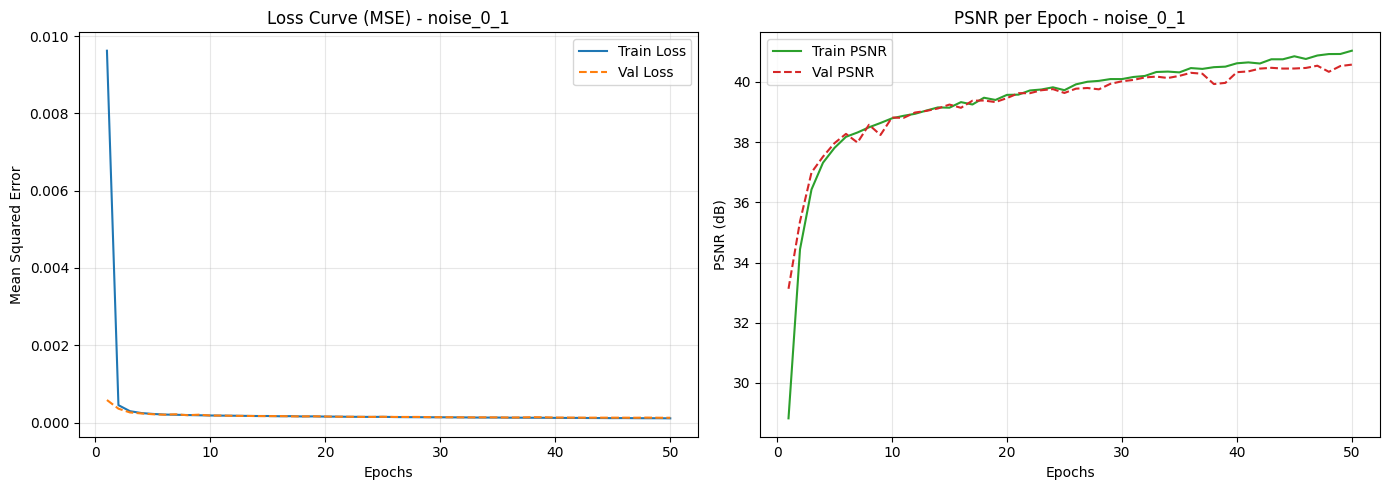

Saved training dashboard: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_training_dashboard.png


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_quantitative_results.txt


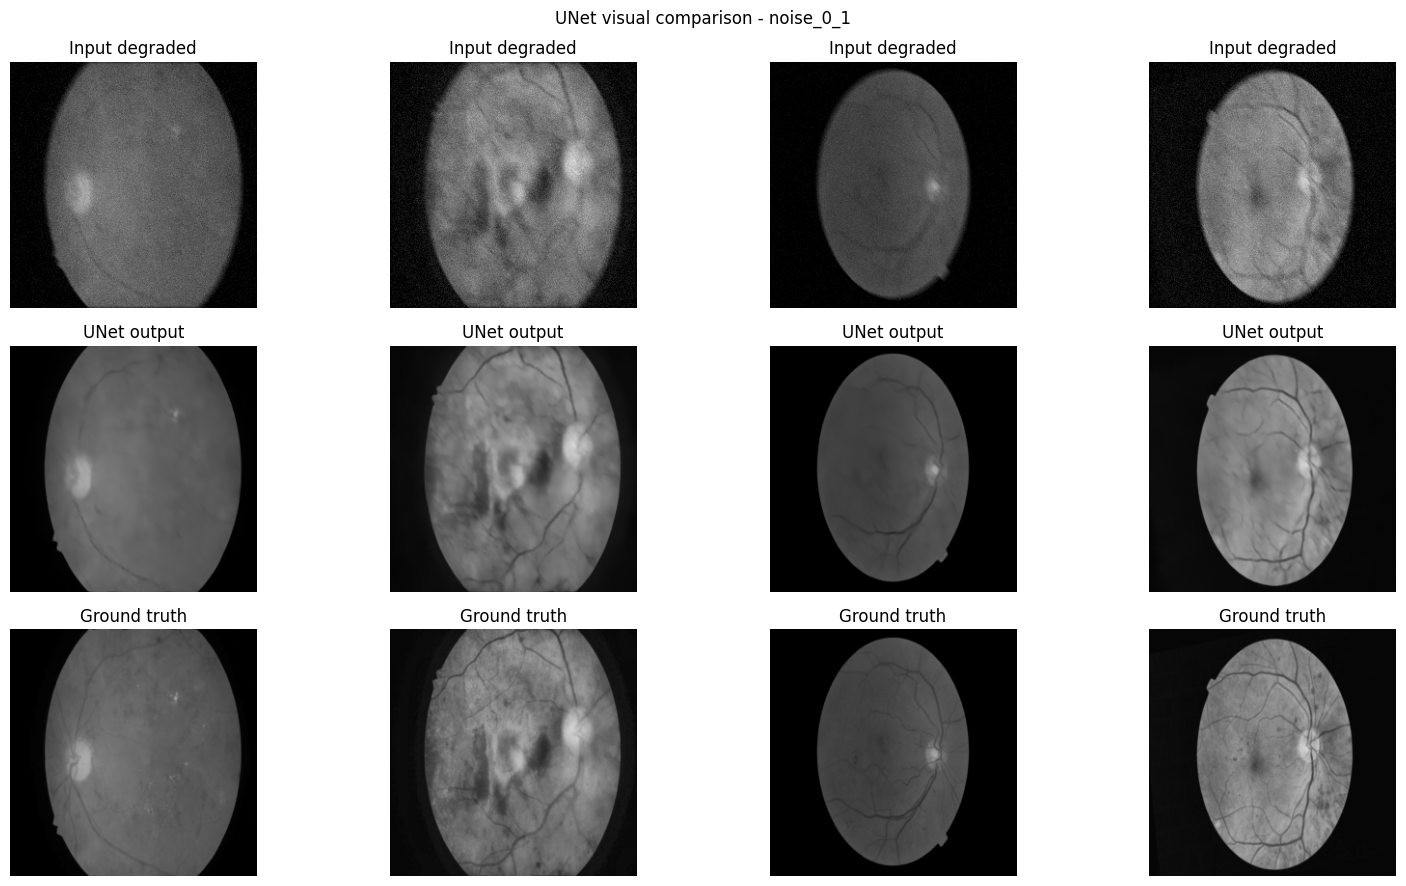

Saved visual grid: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_visual_grid.png


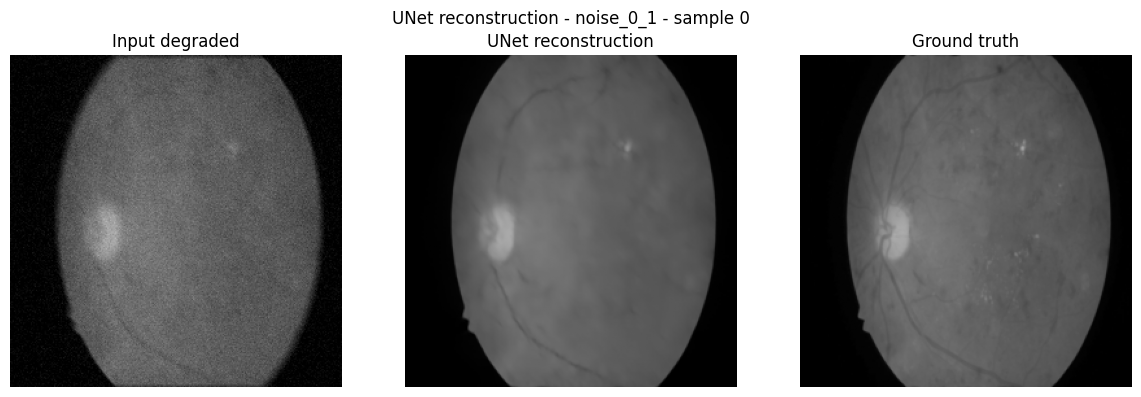

Saved reconstruction: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_reconstruction_sample_0.png


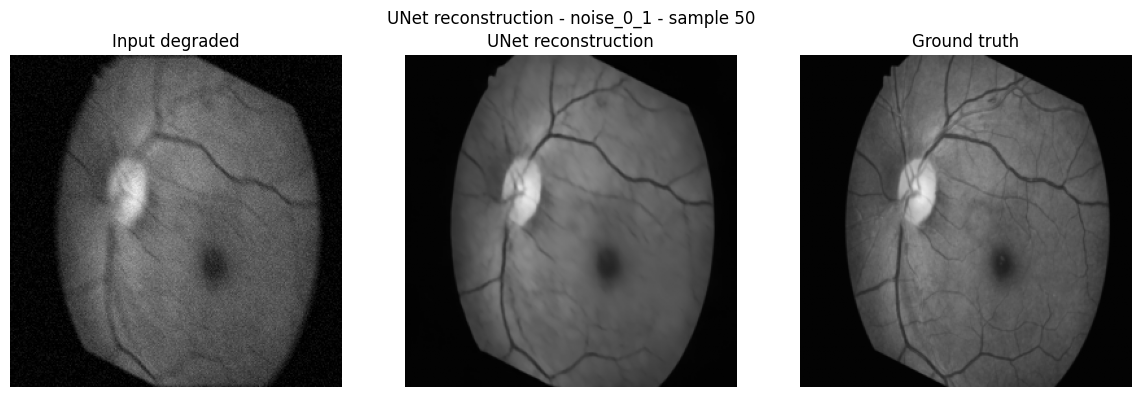

Saved reconstruction: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_reconstruction_sample_50.png


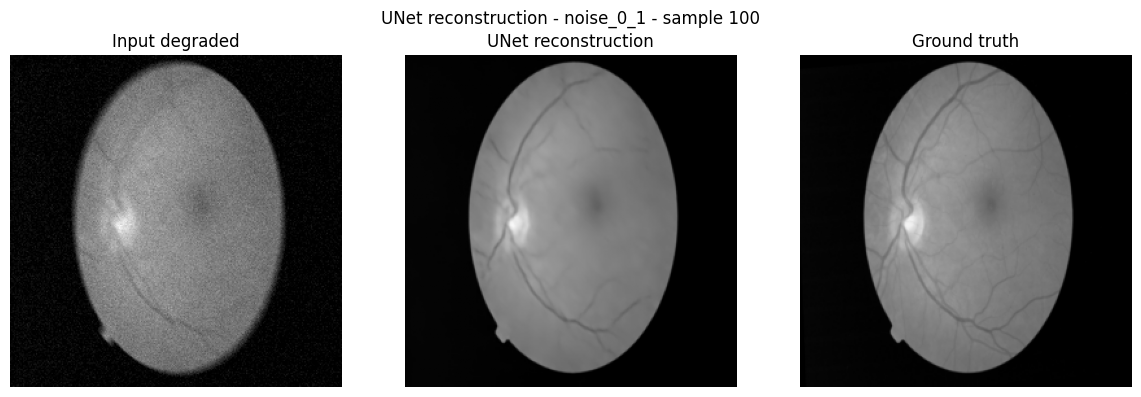

Saved reconstruction: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_reconstruction_sample_100.png


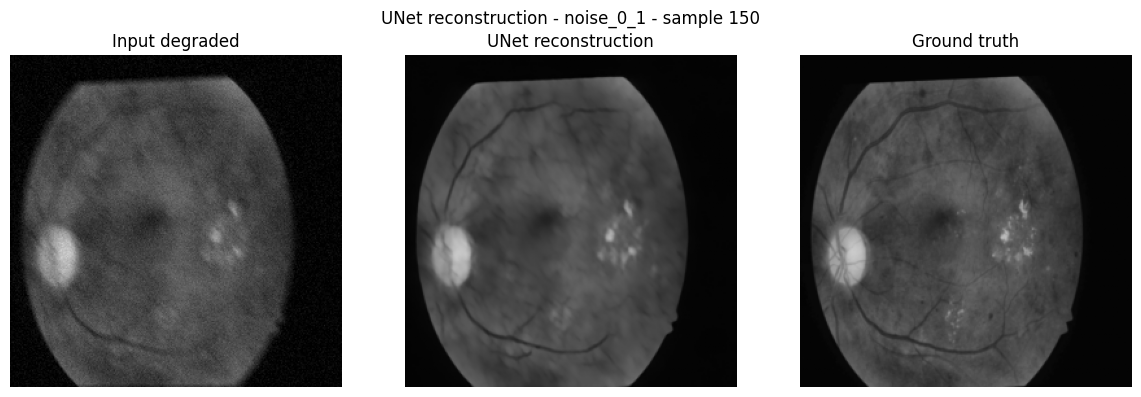

Saved reconstruction: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_reconstruction_sample_150.png
Finished training all degradation levels.


In [16]:

# ============================================================
# TRAIN UNET FOR EACH DEGRADATION LEVEL
# ============================================================

num_epochs = 50
loss_fn = nn.MSELoss()

all_results = []

for noise_level in NOISE_LEVELS:
    print("\n" + "=" * 70)
    print("Training UNet for noise level:", noise_level)
    print("=" * 70)

    train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt = create_dataloaders_for_noise(
        noise_level
    )

    model = UNet(
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
    )

    train_losses = []
    val_losses = []
    train_psnr_values = []
    val_psnr_values = []

    best_val_loss = float("inf")

    tag = noise_tag(noise_level)
    best_model_path = WORK_DIR / f"unet_no_sigmoid_{tag}.pt"

    for epoch in range(num_epochs):
        train_loss, train_psnr = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
        )

        val_loss, val_psnr = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            loss_fn=loss_fn,
            device=device,
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_psnr_values.append(train_psnr)
        val_psnr_values.append(val_psnr)

        print(
            f"Noise {noise_level} | "
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Train PSNR: {train_psnr:.4f} dB | "
            f"Val PSNR: {val_psnr:.4f} dB"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "noise_level": noise_level,
                    "val_loss": best_val_loss,
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "train_psnr": train_psnr_values,
                    "val_psnr": val_psnr_values,
                    "model_type": "UNet no sigmoid",
                    "loss_type": "MSELoss",
                    "num_epochs": num_epochs,
                },
                best_model_path,
            )

            print("Saved best model:", best_model_path)

    # Load best model before evaluation
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    save_training_history(
        train_losses=train_losses,
        val_losses=val_losses,
        train_psnr_values=train_psnr_values,
        val_psnr_values=val_psnr_values,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
    )

    save_training_dashboard(
        train_losses=train_losses,
        val_losses=val_losses,
        train_psnr_values=train_psnr_values,
        val_psnr_values=val_psnr_values,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
    )

    results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    save_quantitative_results(
        results=results,
        noise_level=noise_level,
        best_val_loss=best_val_loss,
        output_dir=OUTPUT_DIR,
    )

    save_grid_reconstruction(
        model=model,
        test_loader=test_loader,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
        n=4,
    )

    save_visual_reconstructions(
        model=model,
        test_dataset=test_dataset_pt,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
        sample_indices=[0, 50, 100, 150],
    )

    all_results.append(
        {
            "noise_level": noise_level,
            "best_val_loss": best_val_loss,
            "psnr_degraded": results["psnr_degraded"],
            "psnr_unet": results["psnr_unet"],
            "psnr_unet_std": results["psnr_unet_std"],
            "psnr_improvement": results["psnr_unet"] - results["psnr_degraded"],
            "mse_degraded": results["mse_degraded"],
            "mse_unet": results["mse_unet"],
            "ssim_degraded": results["ssim_degraded"],
            "ssim_unet": results["ssim_unet"],
            "ssim_unet_std": results["ssim_unet_std"],
            "ssim_improvement": results["ssim_unet"] - results["ssim_degraded"],
            "model_path": str(best_model_path),
        }
    )

print("Finished training all degradation levels.")


## Load Weights

Execute if you already train the models and just want to load weights

In [16]:
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

for noise_level in NOISE_LEVELS:
    train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt = create_dataloaders_for_noise(
        noise_level
    )

    tag = noise_tag(noise_level)

    model = UNet(
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ).to(device)

    best_model_path = WORK_DIR / f"unet_no_sigmoid_{tag}.pt"
    checkpoint = torch.load(best_model_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    check_clamp_impact(
    model=model,
    dataloader=test_loader,
    device=device,
    )

    range_results = check_output_range(
    model=model,
    dataloader=test_loader,
    device=device,
    )

    clamp_results = check_clamp_impact_per_image(
    model=model,
    dataloader=test_loader,
    device=device,
    )

    save_quantitative_results(
        results=results,
        noise_level=noise_level,
        best_val_loss=checkpoint["val_loss"],
        output_dir=OUTPUT_DIR,
    )

Noise level: 0.005
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.005, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Checking clamp impact:   0%|          | 0/75 [00:00<?, ?it/s]

Raw MSE: 0.00003640
Clamped MSE: 0.00003628
Raw PSNR: 44.3895 dB
Clamped PSNR: 44.4030 dB
PSNR gain due to clamp: 0.0135 dB
Negative fraction: 14.2230%
Mean negative value: -0.000652
Mean negative magnitude: 0.000652


Checking output range:   0%|          | 0/75 [00:00<?, ?it/s]

...

Raw MSE: 0.00012607
Clamped MSE: 0.00012604
Raw PSNR: 38.9939 dB
Clamped PSNR: 38.9950 dB
PSNR gain due to clamp: 0.0011 dB
Negative fraction: 3.0625%
Mean negative value: -0.000448
Mean negative magnitude: 0.000448


Checking output range:   0%|          | 0/75 [00:00<?, ?it/s]

Fraction outside [0,1]: 3.062503%
Raw min/max: -0.046359 / 1.024270


Checking clamp impact:   0%|          | 0/75 [00:00<?, ?it/s]

Mean per-image raw MSE: 0.00012607
Mean per-image clamped MSE: 0.00012604
Mean per-image raw PSNR: 40.6192 dB
Mean per-image clamped PSNR: 40.6221 dB
PSNR gain due to clamp: 0.0029 dB
Negative fraction: 3.0625%
Mean negative value: -0.000448
Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_quantitative_results.txt


## Results

In [11]:
# ============================================================
# SAVE SUMMARY RESULTS FOR ALL DEGRADATION LEVELS
# Reading already saved quantitative_results.txt files
# ============================================================

summary_path = OUTPUT_DIR / "summary_all_noise_levels.txt"

noise_levels_for_summary = [0.005, 0.01, 0.05, 0.1]

with open(summary_path, "w") as f:
    f.write("UNet summary results for all degradation levels\n")
    f.write("=" * 60 + "\n\n")

    for noise_level in noise_levels_for_summary:
        tag = noise_tag(noise_level)
        result_path = OUTPUT_DIR / f"{tag}_quantitative_results.txt"

        f.write(f"Noise level: {noise_level}\n")

        if result_path.exists():
            with open(result_path, "r") as result_file:
                content = result_file.read()

            f.write(content)
            f.write("\n")
        else:
            f.write("Results file not found.\n")
            f.write(f"Expected file: {result_path}\n")

        f.write("-" * 60 + "\n\n")

print("Saved summary:", summary_path)

In [12]:
# ============================================================
# PRINT SUMMARY FILE
# ============================================================

with open(summary_path, "r") as f:
    print(f.read())

### Plots

In [17]:

# ============================================================
# PARSE SUMMARY RESULTS FOR ALL DEGRADATION LEVELS
# Reading already saved quantitative_results.txt files
# ============================================================

import re

noise_levels_for_summary = [0.005, 0.01, 0.05, 0.1]

summary_data = []


def parse_float(pattern, content, default=None):
    match = re.search(pattern, content)
    if match:
        return float(match.group(1))
    return default


for noise_level in noise_levels_for_summary:
    tag = noise_tag(noise_level)
    result_path = OUTPUT_DIR / f"{tag}_quantitative_results.txt"

    if not result_path.exists():
        print("Missing file:", result_path)
        continue

    with open(result_path, "r") as f:
        content = f.read()

    row = {
        "noise_level": noise_level,
        "tag": tag,
        "psnr_degraded": parse_float(r"Average PSNR degraded input:\s*([0-9.]+)", content),
        "psnr_degraded_std": parse_float(r"Std PSNR degraded input:\s*([0-9.]+)", content, 0.0),
        "psnr_unet": parse_float(r"Average PSNR UNet output:\s*([0-9.]+)", content),
        "psnr_unet_std": parse_float(r"Std PSNR UNet output:\s*([0-9.]+)", content, 0.0),
        "psnr_improvement": parse_float(r"PSNR improvement:\s*([0-9.]+)", content),
        "mse_degraded": parse_float(r"Average MSE degraded input:\s*([0-9.]+)", content),
        "mse_unet": parse_float(r"Average MSE UNet output:\s*([0-9.]+)", content),
        "ssim_degraded": parse_float(r"Average SSIM degraded input:\s*([0-9.]+)", content),
        "ssim_degraded_std": parse_float(r"Std SSIM degraded input:\s*([0-9.]+)", content, 0.0),
        "ssim_unet": parse_float(r"Average SSIM UNet output:\s*([0-9.]+)", content),
        "ssim_unet_std": parse_float(r"Std SSIM UNet output:\s*([0-9.]+)", content, 0.0),
        "ssim_improvement": parse_float(r"SSIM improvement:\s*([0-9.]+)", content),
    }

    required_keys = [
        "psnr_degraded", "psnr_unet", "psnr_improvement",
        "mse_degraded", "mse_unet",
        "ssim_degraded", "ssim_unet", "ssim_improvement",
    ]

    if all(row[key] is not None for key in required_keys):
        summary_data.append(row)
    else:
        print("Could not parse:", result_path)

print("Parsed results:")
for row in summary_data:
    print(row)


Parsed results:
{'noise_level': 0.005, 'tag': 'noise_0_005', 'psnr_degraded': 33.4069, 'psnr_degraded_std': 2.7838, 'psnr_unet': 46.1534, 'psnr_unet_std': 3.5477, 'psnr_improvement': 12.7465, 'mse_degraded': 0.00054967, 'mse_unet': 3.628e-05, 'ssim_degraded': 0.9212, 'ssim_degraded_std': 0.0338, 'ssim_unet': 0.9839, 'ssim_unet_std': 0.0102, 'ssim_improvement': 0.0628}
{'noise_level': 0.01, 'tag': 'noise_0_01', 'psnr_degraded': 33.3523, 'psnr_degraded_std': 2.7801, 'psnr_unet': 45.658, 'psnr_unet_std': 3.511, 'psnr_improvement': 12.3057, 'mse_degraded': 0.00055615, 'mse_unet': 3.989e-05, 'ssim_degraded': 0.9149, 'ssim_degraded_std': 0.0344, 'ssim_unet': 0.9816, 'ssim_unet_std': 0.0112, 'ssim_improvement': 0.0667}
{'noise_level': 0.05, 'tag': 'noise_0_05', 'psnr_degraded': 31.9894, 'psnr_degraded_std': 2.759, 'psnr_unet': 42.207, 'psnr_unet_std': 3.4729, 'psnr_improvement': 10.2176, 'mse_degraded': 0.00075417, 'mse_unet': 8.666e-05, 'ssim_degraded': 0.7694, 'ssim_degraded_std': 0.0778, '

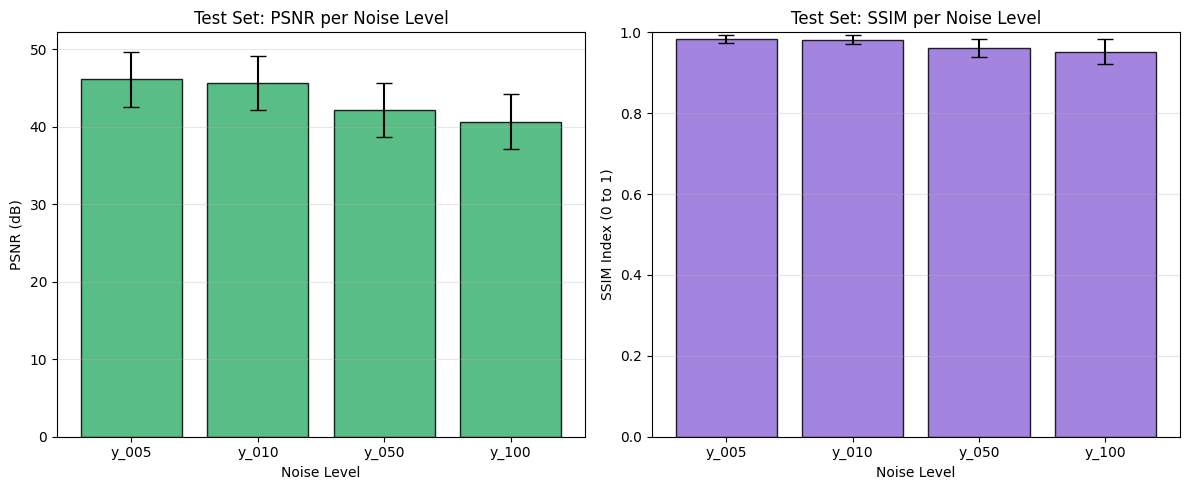

Saved test metric barplots: /content/drive/MyDrive/Computational Imaging/outputs/unet/test_psnr_ssim_barplots_with_std.png


In [18]:

# ============================================================
# SAVE TEST SET PSNR / SSIM BARPLOTS WITH STANDARD DEVIATION
# ============================================================

noise_labels = ["y_005", "y_010", "y_050", "y_100"]
psnr_values = [row["psnr_unet"] for row in summary_data]
psnr_errors = [row["psnr_unet_std"] for row in summary_data]
ssim_values = [row["ssim_unet"] for row in summary_data]
ssim_errors = [row["ssim_unet_std"] for row in summary_data]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    noise_labels,
    psnr_values,
    yerr=psnr_errors,
    capsize=6,
    color="mediumseagreen",
    edgecolor="black",
    alpha=0.85,
)
axes[0].set_title("Test Set: PSNR per Noise Level")
axes[0].set_xlabel("Noise Level")
axes[0].set_ylabel("PSNR (dB)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    noise_labels,
    ssim_values,
    yerr=ssim_errors,
    capsize=6,
    color="mediumpurple",
    edgecolor="black",
    alpha=0.85,
)
axes[1].set_title("Test Set: SSIM per Noise Level")
axes[1].set_xlabel("Noise Level")
axes[1].set_ylabel("SSIM Index (0 to 1)")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()

barplot_path = OUTPUT_DIR / "test_psnr_ssim_barplots_with_std.png"
plt.savefig(barplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved test metric barplots:", barplot_path)


Checking training history files...

All training history files found:
  noise=0.1: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_training_history.pt


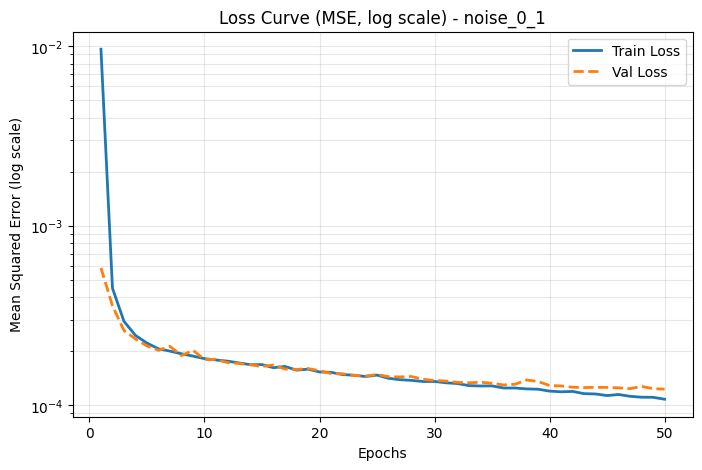

Saved: /content/drive/MyDrive/Computational Imaging/outputs/unet/log_loss_plots/noise_0_1_loss_log_scale.png


In [10]:
# ============================================================
# Verify training history files and plot loss with log scale
# ============================================================

from pathlib import Path
import torch
import matplotlib.pyplot as plt

# If these variables already exist in your notebook, they will be reused.
# Otherwise, set them here.
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("/content/drive/MyDrive/Computational Imaging/Outputs")

try:
    NOISE_LEVELS
except NameError:
    NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

OUTPUT_DIR = Path(OUTPUT_DIR)

def noise_tag(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}"

# ------------------------------------------------------------
# 1. Check that all training_history .pt files exist
# ------------------------------------------------------------

history_paths = {}
missing = []

for noise_level in NOISE_LEVELS:
    tag = noise_tag(noise_level)

    candidates = [
        OUTPUT_DIR / f"{tag}_training_history.pt",
        OUTPUT_DIR / tag / f"{tag}_training_history.pt",
    ]

    found_path = None
    for path in candidates:
        if path.exists():
            found_path = path
            break

    if found_path is None:
        missing.append((noise_level, candidates))
    else:
        history_paths[noise_level] = found_path

print("Checking training history files...\n")

if missing:
    print("Missing training history files:")
    for noise_level, candidates in missing:
        print(f"\nNoise level {noise_level}:")
        for path in candidates:
            print("  Expected:", path)

    raise FileNotFoundError(
        "Some training_history.pt files are missing. "
        "You need those files to redraw the plots without retraining."
    )

print("All training history files found:")
for noise_level, path in history_paths.items():
    print(f"  noise={noise_level}: {path}")

# ------------------------------------------------------------
# 2. Create log-scale loss plots
# ------------------------------------------------------------

LOG_PLOT_DIR = OUTPUT_DIR / "log_loss_plots"
LOG_PLOT_DIR.mkdir(parents=True, exist_ok=True)

for noise_level, history_path in history_paths.items():
    tag = noise_tag(noise_level)

    history = torch.load(history_path, map_location="cpu")

    train_losses = history["train_losses"]
    val_losses = history["val_losses"]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
    plt.plot(epochs, val_losses, "--", label="Val Loss", linewidth=2)

    plt.yscale("log")
    plt.title(f"Loss Curve (MSE, log scale) - {tag}")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error (log scale)")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()

    save_path = LOG_PLOT_DIR / f"{tag}_loss_log_scale.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)